In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
MODELS = Path("../src/models")
FIGURES = Path("../reports/figures")

# Load model and test data
xgb_model = joblib.load(MODELS / "xgboost_baseline.pkl")
X_test = pd.read_parquet(MODELS / "X_test.parquet")

FEATURES = [
    "forecast", "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month",
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]

X_test.columns = FEATURES

print("Model and data loaded")
print("Test set shape:", X_test.shape)

Model and data loaded
Test set shape: (7165, 13)


In [2]:
# TreeExplainer is optimised for XGBoost - very fast
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# Use 1000 samples for speed - still representative
X_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_sample)

print("SHAP values shape:", shap_values.shape)
print("SHAP calculation complete")

SHAP values shape: (1000, 13)
SHAP calculation complete


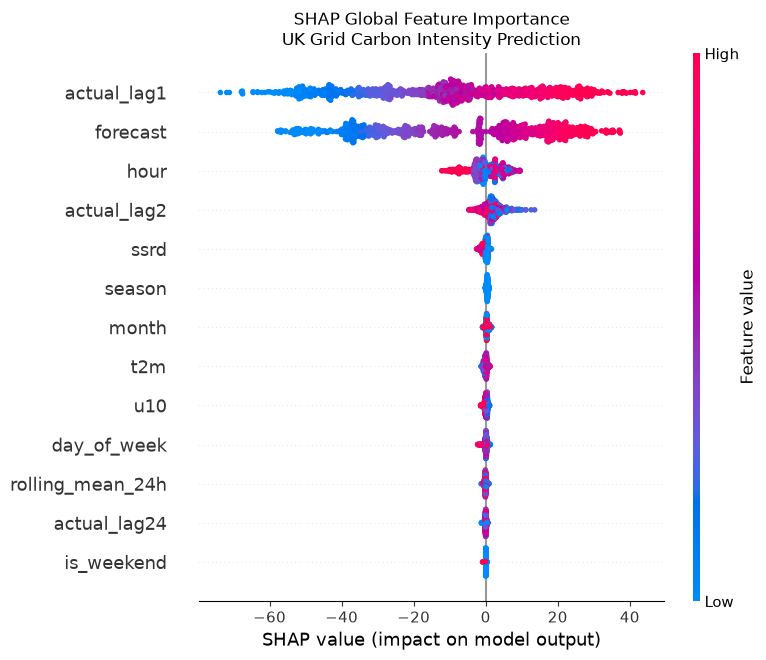

SHAP summary plot saved


In [3]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_sample,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP Global Feature Importance\nUK Grid Carbon Intensity Prediction")
plt.tight_layout()
plt.savefig(FIGURES / "shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved")

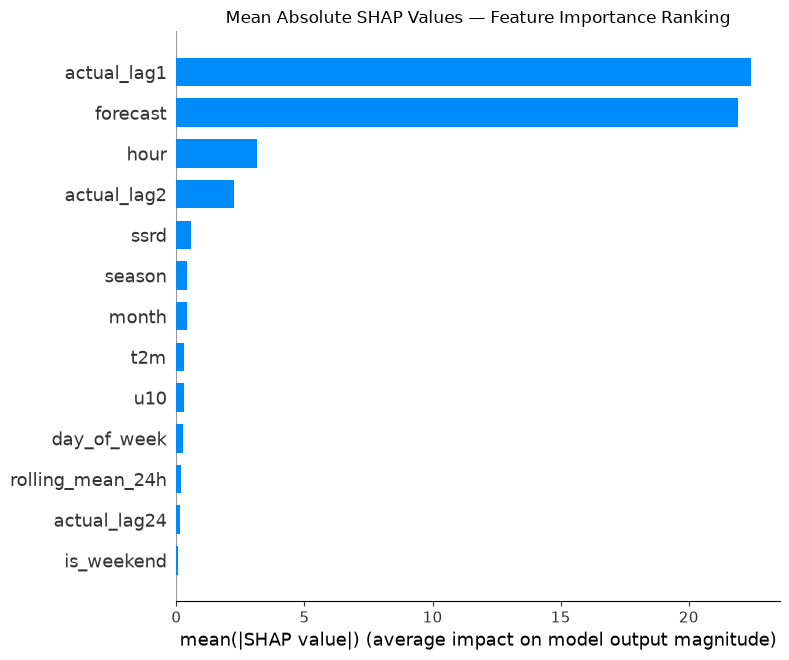

SHAP bar plot saved


In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURES,
    plot_type="bar",
    show=False
)
plt.title("Mean Absolute SHAP Values — Feature Importance Ranking")
plt.tight_layout()
plt.savefig(FIGURES / "shap_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP bar plot saved")

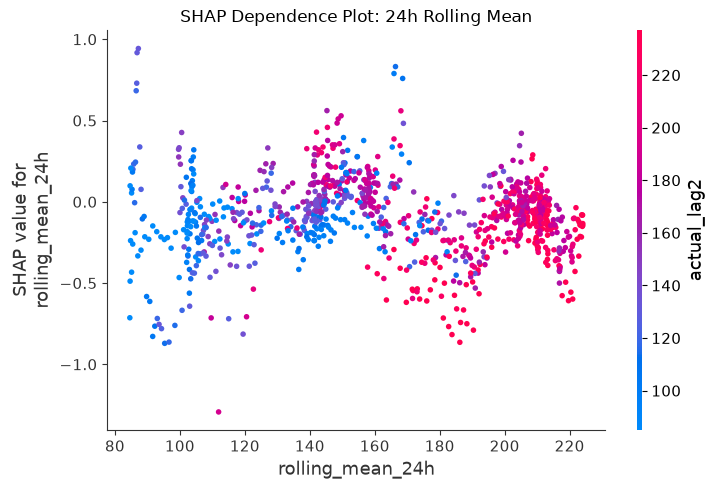

Dependence plot saved


In [5]:
# rolling_mean_24h is likely the top feature
# This shows HOW it affects predictions
shap.dependence_plot(
    "rolling_mean_24h",
    shap_values,
    X_sample,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP Dependence Plot: 24h Rolling Mean")
plt.tight_layout()
plt.savefig(FIGURES / "shap_dependence_rolling_mean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dependence plot saved")

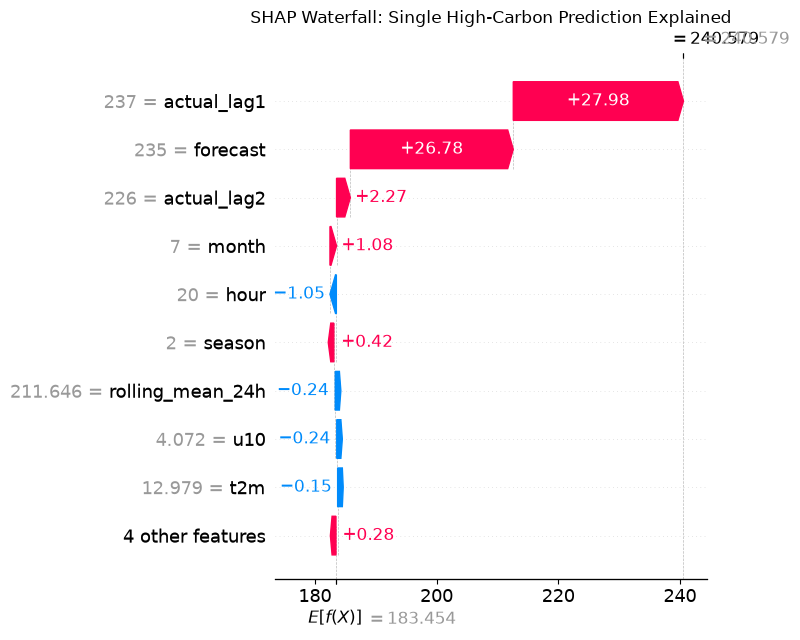

Waterfall plot saved


In [6]:
# Explain one specific prediction in detail
# Pick a high carbon intensity moment
high_carbon_idx = X_sample["actual_lag24"].values.argmax()

shap_explanation = shap.Explanation(
    values=shap_values[high_carbon_idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[high_carbon_idx].values,
    feature_names=FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title("SHAP Waterfall: Single High-Carbon Prediction Explained")
plt.tight_layout()
plt.savefig(FIGURES / "shap_waterfall_single.png", dpi=150, bbox_inches="tight")
plt.show()
print("Waterfall plot saved")

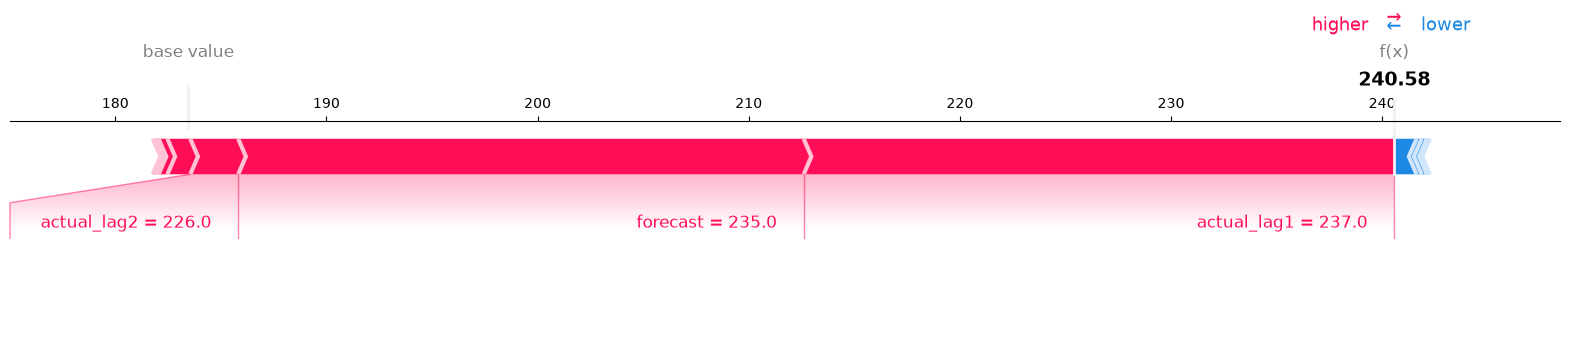

Force plot saved


In [7]:
# Force plot - shows push/pull forces on a single prediction
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[high_carbon_idx],
    X_sample.iloc[high_carbon_idx],
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)
plt.savefig(FIGURES / "shap_force_plot.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Force plot saved")